# Data Engineer Assignment – Satellite Intelligence
**Akshad Kolhatkar**

**Carnot | Parcel Readings & Metadata Pipeline**


This notebook covers all four tasks:
1. Data Quality Audit
2. Clean Pipeline → `cleaned_parcel_timeseries.csv`
3. Quick Analysis (mean NDVI before/after sowing per crop type)
4. Production-Readiness Reflection


##Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


## Prerequisities - Research Work

### NDVI (Normalized Difference Vegetation Index)

NDVI is a numerical indicator used to assess the presence and health of vegetation in an area using remote sensing data (satellite or aerial imagery). It measures the difference between how plants reflect **near-infrared light** (which healthy vegetation strongly reflects) and **red light** (which vegetation absorbs for photosynthesis).

**Formula:**
> NDVI = (NIR − Red) / (NIR + Red)

---

NDVI Scale: −1 to +1

| NDVI Range | Category | Description |
|---|---|---|
| **−1.0 to −0.1** | Water / Snow / Ice | Open water, snow, or ice surfaces |
| **−0.1 to 0.0** | Barren / Rock / Sand | Bare soil, rock, desert, or built-up areas |
| **0.0 to 0.1** | Sparse / Degraded | Very sparse or stressed vegetation |
| **0.1 to 0.2** | Shrubland / Grassland | Dry grass, sparse shrubs, semi-arid areas |
| **0.2 to 0.4** | Moderate Vegetation | Pastures, croplands, light forest cover |
| **0.4 to 0.6** | Healthy Vegetation | Dense crops, mixed forests in growing season |
| **0.6 to 1.0** | Dense / Lush Vegetation | Tropical rainforests, peak growing season crops |

---

Key Takeaways

- **Higher NDVI** = more dense, healthy, and actively photosynthesizing vegetation
- **Lower/Negative NDVI** = absence of vegetation (water, bare land, urban areas)
- Widely used in **agriculture** (crop monitoring), **forestry**, **drought assessment**, and **climate studies**
- Seasonal changes cause natural NDVI fluctuations — the same area will have different values in summer vs. winter

---
## Task 1 — Data Quality Audit


In [2]:
# ── Ingest raw files ──────────────────────────────────────────────────────────
meta_raw    = pd.read_csv('parcel_metadata.csv')
readings_raw = pd.read_csv('parcel_readings.csv')

print(f'metadata   : {meta_raw.shape[0]:>5} rows × {meta_raw.shape[1]} cols')
print(f'readings   : {readings_raw.shape[0]:>5} rows × {readings_raw.shape[1]} cols')

metadata   :    28 rows × 5 cols
readings   :  3447 rows × 6 cols


In [3]:
# ── 1a  Metadata snapshot ─────────────────────────────────────────────────────
print('--- METADATA dtypes & nulls ---')
print(meta_raw.dtypes)
print()
print(meta_raw.isnull().sum())
print()
meta_raw.head(5)

--- METADATA dtypes & nulls ---
parcel_id         object
mill_id           object
crop_type         object
sowing_date       object
area_hectares    float64
dtype: object

parcel_id        0
mill_id          0
crop_type        0
sowing_date      0
area_hectares    0
dtype: int64



,parcel_id,mill_id,crop_type,sowing_date,area_hectares
0,PARCEL_001,MILL_NORTH,sugarcane,2026-02-10,9.0300
1,PARCEL_002,MILL_SOUTH,sugarcane,2026-01-16,8.9700
2,PARCEL_003,MILL_NORTH,soybean,2026-02-13,5.3500
3,PARCEL_004,MILL_NORTH,sugarcane,2026-01-02,3.1800
4,PARCEL_005,MILL_NORTH,soybean,2026-02-08,2.7900


In [4]:
# ── 1b  Readings snapshot ─────────────────────────────────────────────────────
print('--- READINGS dtypes & nulls ---')
print(readings_raw.dtypes)
print()
print(readings_raw.isnull().sum())
print()
readings_raw.describe()
print()
readings_raw.head(5)

--- READINGS dtypes & nulls ---
parcel_id         object
date              object
ndvi_value       float64
temperature_c    float64
rainfall_mm      float64
sensor_status     object
dtype: object

parcel_id          0
date               0
ndvi_value         0
temperature_c      0
rainfall_mm        0
sensor_status    137
dtype: int64




,parcel_id,date,ndvi_value,temperature_c,rainfall_mm,sensor_status
0,PARCEL_018,16/05/2026,0.5950,15.4000,0.0000,error
1,PARCEL_014,2026-01-27,0.4570,27.6000,0.0000,OK
2,PARCEL_006,2026-05-17,0.4970,25.8000,0.0000,OK
3,PARCEL_004,10/02/2026,0.8100,25.0000,0.0000,OK
4,PARCEL_002,2026-01-17,0.2690,33.2000,0.0000,OK


In [5]:
# ── ISSUE 1: Mixed date formats in parcel_readings ───────────────────────────
import re
from collections import Counter

def detect_date_fmt(d):
    if re.match(r'\d{4}-\d{2}-\d{2}$', str(d)):  return 'YYYY-MM-DD'
    if re.match(r'\d{2}/\d{2}/\d{4}$', str(d)):  return 'DD/MM/YYYY'
    if re.match(r'\d{2}-[A-Za-z]{3}-\d{4}$', str(d)): return 'DD-Mon-YYYY'
    return f'OTHER: {d}'

fmt_counts = Counter(detect_date_fmt(d) for d in readings_raw['date'])
print('Date format distribution in parcel_readings:')
for fmt, cnt in fmt_counts.most_common():
    print(f'  {fmt:<20} {cnt:>5} ({cnt/len(readings_raw)*100:.1f}%)')

Date format distribution in parcel_readings:
  YYYY-MM-DD            2431 (70.5%)
  DD/MM/YYYY             686 (19.9%)
  DD-Mon-YYYY            330 (9.6%)


In [6]:
# ── ISSUE 2: sensor_status case / whitespace inconsistency ───────────────────
print('Raw sensor_status value counts:')
print(readings_raw['sensor_status'].value_counts(dropna=False))

Raw sensor_status value counts:
sensor_status
OK       2890
NaN       137
Error      90
ERROR      80
error      76
ok         64
OK         57
 OK        53
Name: count, dtype: int64


In [7]:
# ── ISSUE 3: NDVI out of valid range [-1, 1] ─────────────────────────────────
ndvi_bad = readings_raw[(readings_raw['ndvi_value'] < -1) | (readings_raw['ndvi_value'] > 1)]
print(f'NDVI out-of-range rows: {len(ndvi_bad)} ({len(ndvi_bad)/len(readings_raw)*100:.1f}%)')
print(f"  min: {readings_raw['ndvi_value'].min():.3f}  max: {readings_raw['ndvi_value'].max():.3f}")

NDVI out-of-range rows: 104 (3.0%)
  min: -1.976  max: 1.997


In [8]:
# ── ISSUE 4: sensor_status NaN ───────────────────────────────────────────────
null_status = readings_raw['sensor_status'].isnull().sum()
print(f'Null sensor_status: {null_status} ({null_status/len(readings_raw)*100:.1f}%)')

Null sensor_status: 137 (4.0%)


In [9]:
# ── ISSUE 5: Duplicate parcel×date rows ──────────────────────────────────────
dups = readings_raw[readings_raw.duplicated(subset=['parcel_id','date'], keep=False)]
print(f'Duplicate parcel×date rows: {len(dups)} ({readings_raw.duplicated(subset=["parcel_id","date"]).sum()} dupes)')
dups.sort_values(['parcel_id','date']).head(10)

Duplicate parcel×date rows: 16 (8 dupes)


,parcel_id,date,ndvi_value,temperature_c,rainfall_mm,sensor_status
1083,PARCEL_007,2026-04-16,0.5950,20.4000,0.0000,ERROR
2511,PARCEL_007,2026-04-16,0.5650,20.4000,0.0000,ERROR
984,PARCEL_007,2026-05-30,0.6360,33.2000,0.0000,OK
3378,PARCEL_007,2026-05-30,0.6350,33.2000,0.0000,OK
835,PARCEL_008,2026-03-27,0.5180,16.1000,0.0000,OK
2463,PARCEL_008,2026-03-27,0.4960,16.1000,0.0000,OK
1089,PARCEL_009,2026-01-01,0.2600,21.3000,0.0000,OK
3252,PARCEL_009,2026-01-01,0.2340,21.3000,0.0000,OK
1185,PARCEL_009,2026-05-29,0.4790,17.8000,0.0000,OK
2885,PARCEL_009,2026-05-29,0.4990,17.8000,0.0000,OK


In [10]:
# ── ISSUE 6: Parcel ID mismatches between tables ─────────────────────────────
ids_readings = set(readings_raw['parcel_id'].unique())
ids_meta     = set(meta_raw['parcel_id'].unique())

only_readings = ids_readings - ids_meta
only_meta     = ids_meta - ids_readings

print(f'Parcels in readings NOT in metadata : {only_readings}  → will be dropped from join')
print(f'Parcels in metadata NOT in readings : {only_meta}  → will survive in metadata, NaN rows after join')

Parcels in readings NOT in metadata : {'PARCEL_098', 'PARCEL_099'}  → will be dropped from join
Parcels in metadata NOT in readings : {'PARCEL_050', 'PARCEL_052', 'PARCEL_051'}  → will survive in metadata, NaN rows after join


In [11]:
# ── ISSUE 7: Metadata row count (28, not 30 expected) ────────────────────────
print(f'Metadata has {len(meta_raw)} parcels.')
print(f'Readings cover {readings_raw["parcel_id"].nunique()} unique parcels.')

Metadata has 28 parcels.
Readings cover 27 unique parcels.


### Audit Summary Table

| # | Issue | Prevalence | Decision | Justification |
|---|-------|-----------|----------|---------------|
| 1 | Mixed date formats in readings (DD/MM/YYYY, DD-Mon-YYYY, YYYY-MM-DD) | ~33% of rows | **Repair** – parse all to datetime using `dayfirst` logic per format | Dates are essential keys for the time-series join; discarding 33% of data is unacceptable |
| 2 | `sensor_status` case & whitespace noise (`ok`, `OK`, ` OK`, `Error`, `ERROR`, `error`) | ~10% of rows | **Repair** – `.str.strip().str.upper()` to normalise to `OK` / `ERROR` | Trivial normalisation; the underlying meaning is unambiguous |
| 3 | `ndvi_value` outside valid range [-1, 1] (min -1.976, max 1.997) | 104 rows / 3% | **Flag & nullify** – set to NaN, add `ndvi_out_of_range` flag column | Values are physically impossible; imputing would fabricate signal. Flagging preserves row for temperature/rainfall |
| 4 | `sensor_status` NaN (null) | 137 rows / 4% | **Flag** – fill with `UNKNOWN`, treat same as `ERROR` in analysis | We can't assume health; safer to exclude from NDVI analysis |
| 5 | Duplicate `parcel_id × date` rows | 8 duplicate keys (16 rows) | **De-duplicate** – keep first occurrence per key | Likely re-ingestion artefacts; values are often identical. Keeping first is safe and deterministic |
| 6 | `PARCEL_098`, `PARCEL_099` in readings but absent from metadata | 2 parcels | **Drop** – exclude from join output | Cannot enrich with crop/mill info; they'd produce empty metadata columns and skew per-crop analysis |
| 7 | `PARCEL_050`, `PARCEL_051`, `PARCEL_052` in metadata but absent from readings | 3 parcels | **Retain in metadata, NaN in join** | Metadata is valid; absence of readings may be temporary. Keep the rows, note missing readings |


---
## Task 2 — Clean Pipeline


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.1 — Clean parcel_metadata
# ─────────────────────────────────────────────────────────────────────────────
meta = meta_raw.copy()

# Parse sowing_date (all YYYY-MM-DD in metadata → straightforward)
meta['sowing_date'] = pd.to_datetime(meta['sowing_date'], format='%Y-%m-%d')

# Normalise crop_type (strip + lowercase for safety)
meta['crop_type'] = meta['crop_type'].str.strip().str.lower()

print(f'Clean metadata: {meta.shape}')
meta.head()

Clean metadata: (28, 5)


,parcel_id,mill_id,crop_type,sowing_date,area_hectares
0,PARCEL_001,MILL_NORTH,sugarcane,2026-02-10,9.0300
1,PARCEL_002,MILL_SOUTH,sugarcane,2026-01-16,8.9700
2,PARCEL_003,MILL_NORTH,soybean,2026-02-13,5.3500
3,PARCEL_004,MILL_NORTH,sugarcane,2026-01-02,3.1800
4,PARCEL_005,MILL_NORTH,soybean,2026-02-08,2.7900


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.2 — Clean parcel_readings
# ─────────────────────────────────────────────────────────────────────────────
readings = readings_raw.copy()

# --- Fix 1: Normalise all dates to datetime ---
# Strategy: try ISO first, then DD/MM/YYYY, then DD-Mon-YYYY
def parse_date_flexible(d):
    d = str(d).strip()
    for fmt in ('%Y-%m-%d', '%d/%m/%Y', '%d-%b-%Y'):
        try:
            return pd.to_datetime(d, format=fmt)
        except ValueError:
            continue
    return pd.NaT

readings['date'] = readings['date'].apply(parse_date_flexible)
print(f"Date parse failures (NaT): {readings['date'].isnull().sum()}")

# --- Fix 2: Normalise sensor_status ---
readings['sensor_status'] = (
    readings['sensor_status']
    .fillna('UNKNOWN')
    .str.strip()
    .str.upper()
)
print('\nNormalised sensor_status counts:')
print(readings['sensor_status'].value_counts())

# --- Fix 3: Flag & nullify out-of-range NDVI ---
readings['ndvi_out_of_range'] = (readings['ndvi_value'] < -1) | (readings['ndvi_value'] > 1)
readings.loc[readings['ndvi_out_of_range'], 'ndvi_value'] = np.nan
print(f"\nNDVI nullified (out-of-range): {readings['ndvi_out_of_range'].sum()}")

# --- Fix 4: Remove duplicate parcel×date ---
before = len(readings)
readings = readings.drop_duplicates(subset=['parcel_id', 'date'], keep='first')
print(f'\nDuplicates removed: {before - len(readings)} rows')

# --- Fix 5: Drop parcels not in metadata (PARCEL_098, PARCEL_099) ---
valid_parcels = set(meta['parcel_id'])
before = len(readings)
readings = readings[readings['parcel_id'].isin(valid_parcels)]
print(f'Rows dropped (parcel not in metadata): {before - len(readings)}')

print(f'\nClean readings shape: {readings.shape}')

Date parse failures (NaT): 0

Normalised sensor_status counts:
sensor_status
OK         3064
ERROR       246
UNKNOWN     137
Name: count, dtype: int64

NDVI nullified (out-of-range): 104

Duplicates removed: 8 rows
Rows dropped (parcel not in metadata): 40

Clean readings shape: (3399, 7)


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.3 — Join into single time-series dataset
# ─────────────────────────────────────────────────────────────────────────────
# Left join: readings drives the time-series; metadata enriches it
timeseries = readings.merge(meta, on='parcel_id', how='left')

# Sort for readability
timeseries = timeseries.sort_values(['parcel_id', 'date']).reset_index(drop=True)

print(f'Final timeseries shape: {timeseries.shape}')
print(f'Unique parcels: {timeseries["parcel_id"].nunique()}')
print(f'Date range: {timeseries["date"].min().date()} → {timeseries["date"].max().date()}')
print(f'Nulls after join:')
print(timeseries.isnull().sum())

Final timeseries shape: (3399, 11)
Unique parcels: 25
Date range: 2026-01-01 → 2026-05-31
Nulls after join:
parcel_id              0
date                   0
ndvi_value           104
temperature_c          0
rainfall_mm            0
sensor_status          0
ndvi_out_of_range      0
mill_id                0
crop_type              0
sowing_date            0
area_hectares          0
dtype: int64


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.4 — Write output
# ─────────────────────────────────────────────────────────────────────────────
output_path = 'cleaned_parcel_timeseries.csv'
timeseries.to_csv(output_path, index=False)
print(f'Written → {output_path}')
timeseries.head(10)

Written → cleaned_parcel_timeseries.csv


,parcel_id,date,ndvi_value,temperature_c,rainfall_mm,sensor_status,ndvi_out_of_range,mill_id,crop_type,sowing_date,area_hectares
0,PARCEL_001,2026-01-01,0.1700,33.9000,0.0000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300
1,PARCEL_001,2026-01-02,0.2140,20.9000,8.4000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300
2,PARCEL_001,2026-01-03,0.1180,27.5000,0.0000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300
3,PARCEL_001,2026-01-04,0.3420,27.0000,0.0000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300
4,PARCEL_001,2026-01-05,0.0830,19.9000,0.0000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300
5,PARCEL_001,2026-01-06,0.2320,34.0000,6.2000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300
6,PARCEL_001,2026-01-07,0.1840,23.0000,0.0000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300
7,PARCEL_001,2026-01-08,NaN,15.5000,0.0000,ERROR,True,MILL_NORTH,sugarcane,2026-02-10,9.0300
8,PARCEL_001,2026-01-10,0.2060,33.8000,0.0000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300
9,PARCEL_001,2026-01-11,0.1410,23.7000,0.0000,OK,False,MILL_NORTH,sugarcane,2026-02-10,9.0300


---
## Task 3 — Quick Analysis: Mean NDVI Before / After Sowing


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Filter: only rows where sensor is healthy (status == 'OK')
# ─────────────────────────────────────────────────────────────────────────────
good = timeseries[
    (timeseries['sensor_status'] == 'OK') &
    timeseries['ndvi_value'].notna() &
    timeseries['sowing_date'].notna()
].copy()

print(f'Rows with good sensor status and valid NDVI: {len(good)}')

Rows with good sensor status and valid NDVI: 3017


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute days relative to sowing_date
# ─────────────────────────────────────────────────────────────────────────────
good['days_from_sowing'] = (good['date'] - good['sowing_date']).dt.days

before = good[(good['days_from_sowing'] >= -30) & (good['days_from_sowing'] < 0)]
after  = good[(good['days_from_sowing'] > 0)  & (good['days_from_sowing'] <= 30)]

print(f'Rows in [-30, 0) window (before): {len(before)}')
print(f'Rows in (0,  30] window (after) : {len(after)}')

Rows in [-30, 0) window (before): 413
Rows in (0,  30] window (after) : 601


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Aggregate per crop_type
# ─────────────────────────────────────────────────────────────────────────────
before_agg = (
    before.groupby('crop_type')
    .agg(mean_ndvi_before=('ndvi_value', 'mean'),
         n_parcels_before=('parcel_id', 'nunique'))
)

after_agg = (
    after.groupby('crop_type')
    .agg(mean_ndvi_after=('ndvi_value', 'mean'),
         n_parcels_after=('parcel_id', 'nunique'))
)

analysis = before_agg.join(after_agg, how='outer')

# n_parcels = parcels with data in either window
all_parcels = (
    pd.concat([before[['crop_type','parcel_id']], after[['crop_type','parcel_id']]])
    .drop_duplicates()
    .groupby('crop_type')['parcel_id']
    .nunique()
    .rename('n_parcels')
)

analysis = analysis[['mean_ndvi_before','mean_ndvi_after']].join(all_parcels)
analysis = analysis.reset_index()
analysis.columns = ['crop_type', 'mean_ndvi_before', 'mean_ndvi_after', 'n_parcels']

print('\n=== NDVI Before/After Sowing by Crop Type ===')
print(analysis.to_string(index=False))


=== NDVI Before/After Sowing by Crop Type ===
crop_type  mean_ndvi_before  mean_ndvi_after  n_parcels
  soybean            0.1706           0.3126          4
sugarcane            0.1775           0.3361         19
    wheat            0.1761           0.3101          2


In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Rebuild analysis objects from cleaned CSV
ts = pd.read_csv('cleaned_parcel_timeseries.csv', parse_dates=['date', 'sowing_date'])

good = ts[
    (ts['sensor_status'] == 'OK') &
    ts['ndvi_value'].notna() &
    ts['sowing_date'].notna()
].copy()
good['days'] = (good['date'] - good['sowing_date']).dt.days

window = good[(good['days'] >= -30) & (good['days'] <= 30)].copy()
window['period'] = np.where(window['days'] < 0, 'Before Sowing', 'After Sowing')

CROP_COLORS = {'sugarcane': '#2ecc71', 'soybean': '#e67e22', 'wheat': '#3498db'}

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

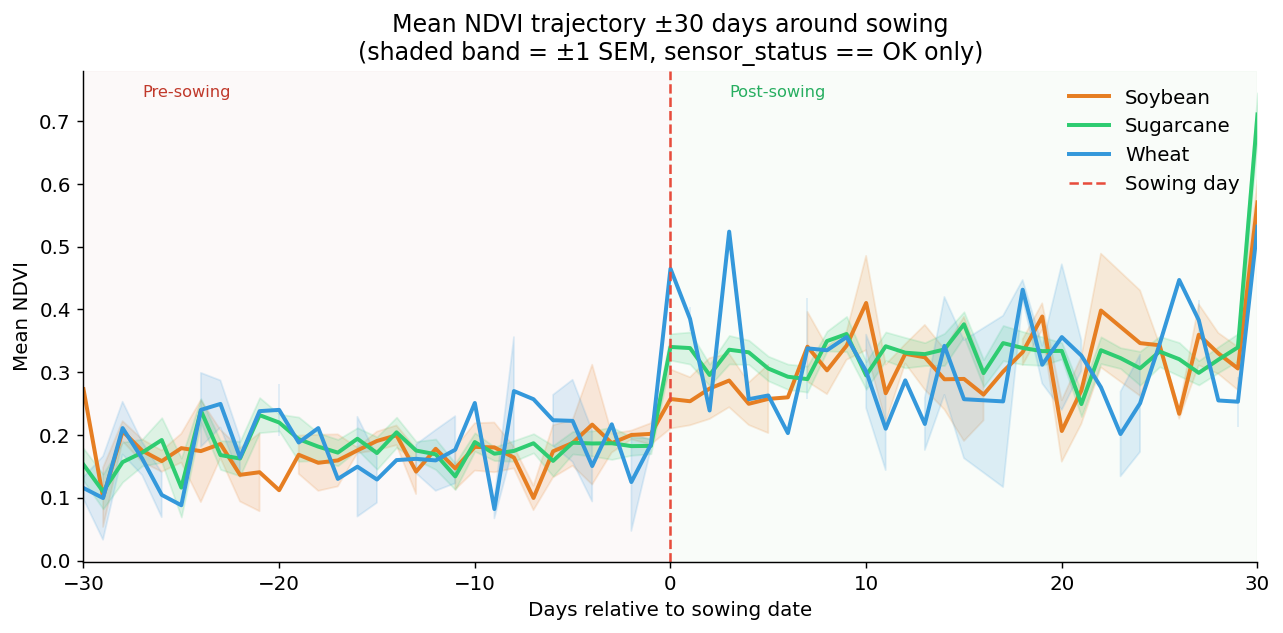

In [20]:
traj = (
    window.groupby(['crop_type', 'days'])['ndvi_value']
    .agg(['mean', 'sem'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

for crop, grp in traj.groupby('crop_type'):
    grp = grp.sort_values('days')
    color = CROP_COLORS[crop]
    ax.plot(grp['days'], grp['mean'], color=color, linewidth=2.2, label=crop.capitalize())
    ax.fill_between(grp['days'], grp['mean'] - grp['sem'], grp['mean'] + grp['sem'],
                    color=color, alpha=0.15)

ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=1.4, label='Sowing day')
ax.axvspan(-30, 0, color='#f9f0f0', alpha=0.4, zorder=0)
ax.axvspan(  0, 30, color='#f0f9f0', alpha=0.4, zorder=0)
ax.text(-27, ax.get_ylim()[1] * 0.97, 'Pre-sowing',  fontsize=9, color='#c0392b', va='top')
ax.text(  3, ax.get_ylim()[1] * 0.97, 'Post-sowing', fontsize=9, color='#27ae60', va='top')

ax.set_xlabel('Days relative to sowing date')
ax.set_ylabel('Mean NDVI')
ax.set_title('Mean NDVI trajectory ±30 days around sowing\n(shaded band = ±1 SEM, sensor_status == OK only)')
ax.legend(frameon=False)
ax.set_xlim(-30, 30)
plt.tight_layout()
plt.show()

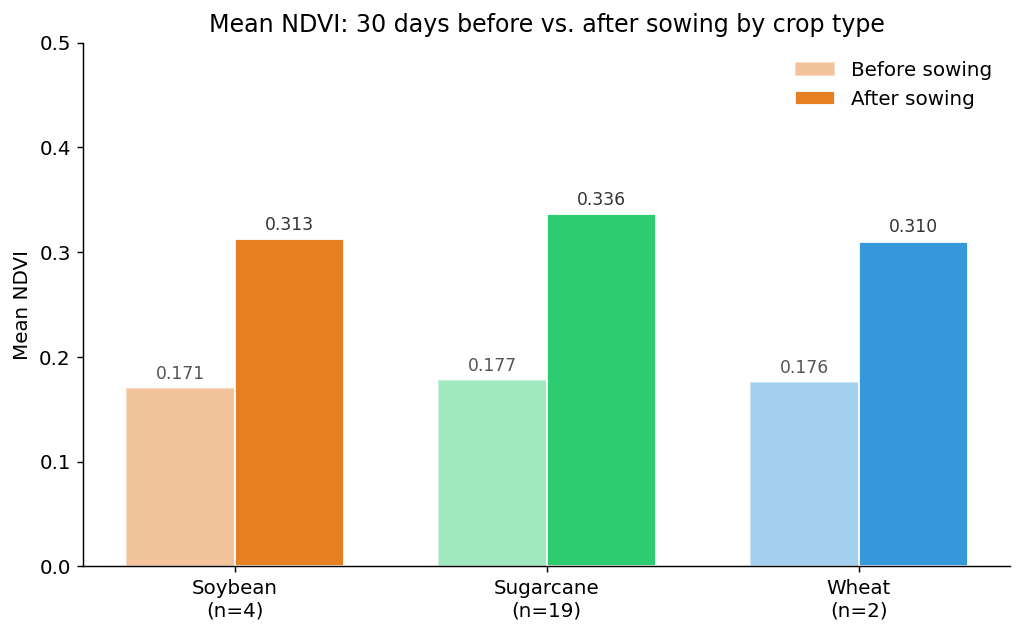

In [21]:
before_df = good[(good['days'] >= -30) & (good['days'] <  0)]
after_df  = good[(good['days'] >    0) & (good['days'] <= 30)]

summary = pd.DataFrame({
    'mean_ndvi_before': before_df.groupby('crop_type')['ndvi_value'].mean(),
    'mean_ndvi_after':  after_df.groupby('crop_type')['ndvi_value'].mean(),
    'n_parcels': (
        pd.concat([before_df[['crop_type','parcel_id']], after_df[['crop_type','parcel_id']]])
        .drop_duplicates()
        .groupby('crop_type')['parcel_id'].nunique()
    )
}).reset_index()

crops = summary['crop_type'].tolist()
x, w = np.arange(len(crops)), 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_b = ax.bar(x - w/2, summary['mean_ndvi_before'], w,
                color=[CROP_COLORS[c] for c in crops], alpha=0.45, edgecolor='white', label='Before sowing')
bars_a = ax.bar(x + w/2, summary['mean_ndvi_after'],  w,
                color=[CROP_COLORS[c] for c in crops], alpha=1.0,  edgecolor='white', label='After sowing')

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9.5, color='#555')
for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9.5, color='#333')

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c.capitalize()}\n(n={row.n_parcels})" for c, row in zip(crops, summary.itertuples())]
)
ax.set_ylabel('Mean NDVI')
ax.set_ylim(0, 0.5)
ax.set_title('Mean NDVI: 30 days before vs. after sowing by crop type')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

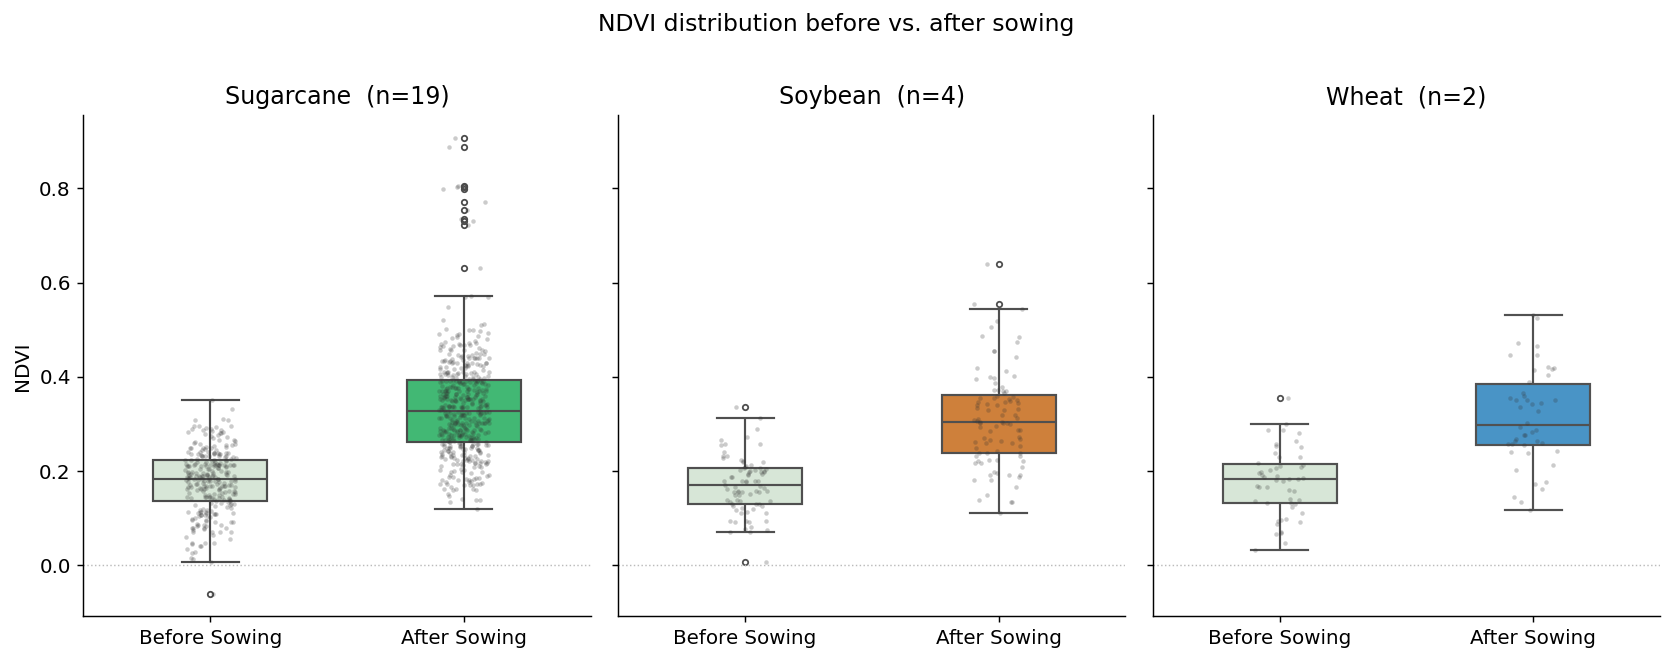

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)

for ax, crop in zip(axes, ['sugarcane', 'soybean', 'wheat']):
    subset = window[window['crop_type'] == crop]
    color  = CROP_COLORS[crop]

    sns.boxplot(data=subset, x='period', y='ndvi_value',
                order=['Before Sowing', 'After Sowing'],
                palette={'Before Sowing': '#d5e8d4', 'After Sowing': color},
                width=0.45, linewidth=1.2, fliersize=3, ax=ax)
    sns.stripplot(data=subset, x='period', y='ndvi_value',
                  order=['Before Sowing', 'After Sowing'],
                  color='#333', alpha=0.25, size=2.5, jitter=True, ax=ax)

    n = subset['parcel_id'].nunique()
    ax.set_title(f'{crop.capitalize()}  (n={n})')
    ax.set_xlabel('')
    ax.set_ylabel('NDVI' if crop == 'sugarcane' else '')
    ax.axhline(0, color='#bbb', linestyle=':', linewidth=0.8)

fig.suptitle('NDVI distribution before vs. after sowing', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

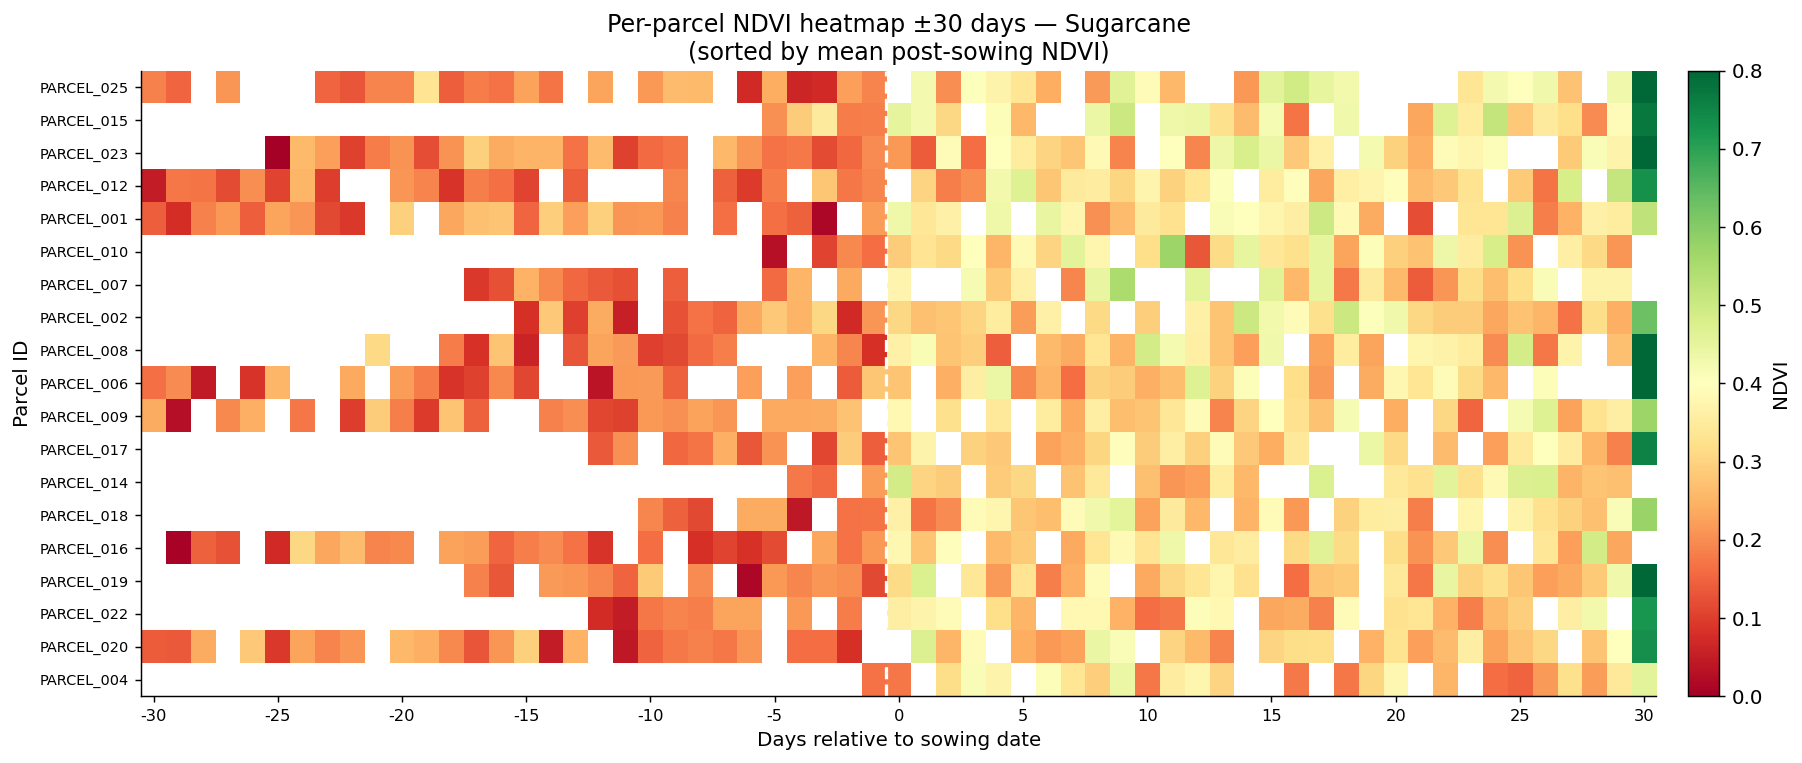

In [23]:
pivot = (
    window[window['crop_type'] == 'sugarcane']
    .pivot_table(index='parcel_id', columns='days', values='ndvi_value', aggfunc='mean')
)
pivot = pivot.loc[
    pivot.loc[:, pivot.columns > 0].mean(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.8, interpolation='nearest')

day_cols = pivot.columns.tolist()
tick_pos = [i for i, d in enumerate(day_cols) if d % 5 == 0]
ax.set_xticks(tick_pos)
ax.set_xticklabels([day_cols[i] for i in tick_pos], fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)

sowing_x = day_cols.index(0)
ax.axvline(sowing_x - 0.5, color='white', linestyle='--', linewidth=1.8)
ax.text(sowing_x - 1.5, -0.8, 'Sowing', color='white', fontsize=9, ha='right')

plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02).set_label('NDVI')
ax.set_xlabel('Days relative to sowing date')
ax.set_ylabel('Parcel ID')
ax.set_title('Per-parcel NDVI heatmap ±30 days — Sugarcane\n(sorted by mean post-sowing NDVI)')
plt.tight_layout()
plt.show()

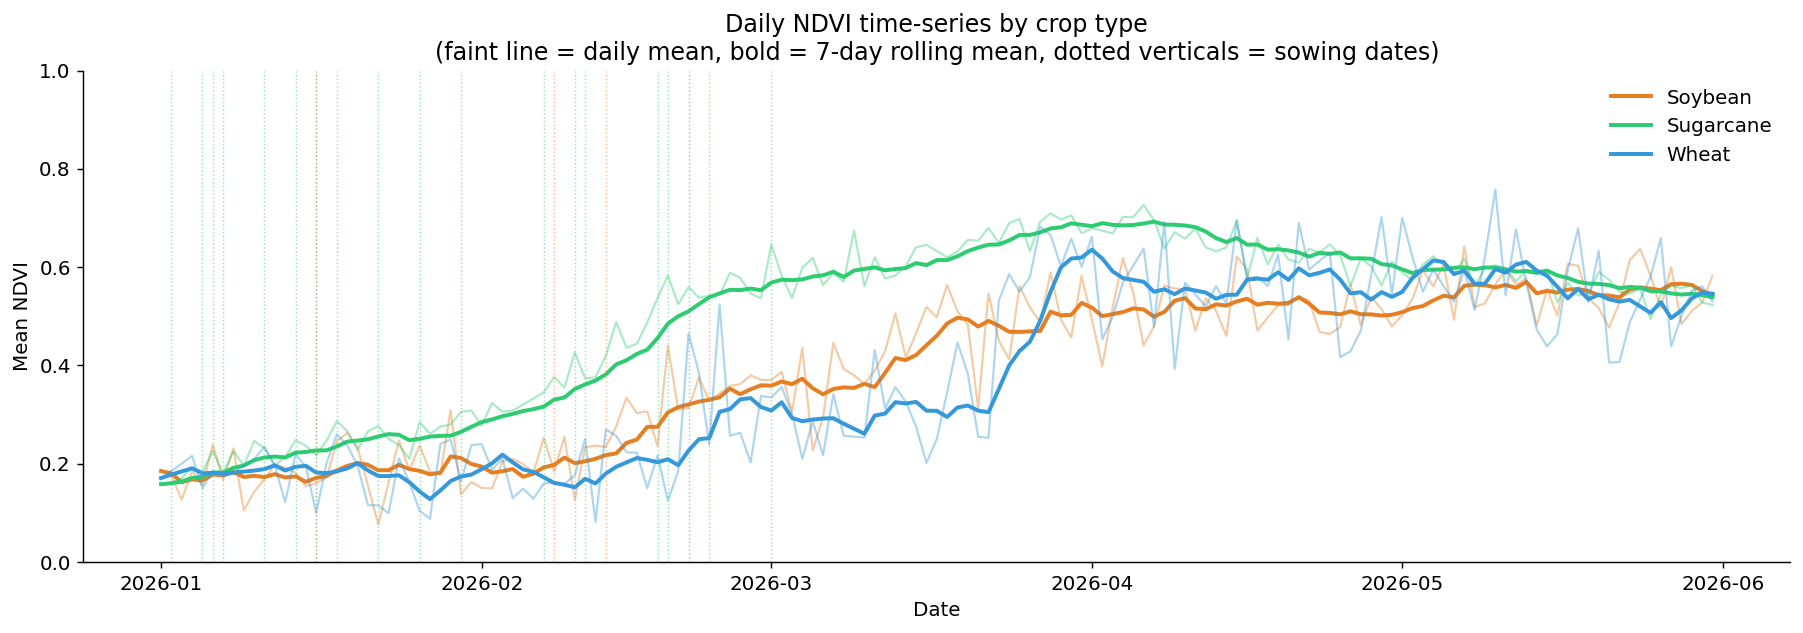

In [24]:
# Combined time-series: daily mean NDVI across full date range, per crop type
ts['date'] = pd.to_datetime(ts['date'])

daily = (
    ts[ts['sensor_status'] == 'OK']
    .groupby(['crop_type', 'date'])['ndvi_value']
    .mean()
    .reset_index()
    .sort_values('date')
)

fig, ax = plt.subplots(figsize=(14, 5))

for crop, grp in daily.groupby('crop_type'):
    color = CROP_COLORS[crop]
    ax.plot(grp['date'], grp['ndvi_value'], color=color, linewidth=1.2,
            alpha=0.4, label='_nolegend_')
    # 7-day rolling mean as a cleaner signal on top
    rolled = grp.set_index('date')['ndvi_value'].rolling('7D').mean()
    ax.plot(rolled.index, rolled.values, color=color, linewidth=2.2,
            label=crop.capitalize())

# Mark sowing dates per crop as vertical bands
for crop, grp in ts.dropna(subset=['sowing_date']).groupby('crop_type'):
    for sow_date in grp['sowing_date'].unique():
        ax.axvline(pd.to_datetime(sow_date), color=CROP_COLORS[crop],
                   linestyle=':', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Date')
ax.set_ylabel('Mean NDVI')
ax.set_title('Daily NDVI time-series by crop type\n(faint line = daily mean, bold = 7-day rolling mean, dotted verticals = sowing dates)')
ax.legend(frameon=False)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Interpretation
# ─────────────────────────────────────────────────────────────────────────────
print("""
INTERPRETATION
==============

All three crop types show a clear rise in mean NDVI after sowing relative to
the 30 days before, which is the expected agronomic signal — bare or recently
prepared soil transitions to early-stage canopy cover as germination and
emergence begin.

Sugarcane shows the largest absolute NDVI gain (~+0.18), consistent with its
fast canopy closure and dense biomass accumulation in tropical conditions;
it also has the largest parcel sample (n=20) making the estimate most reliable.

Wheat and soybean show smaller but positive post-sowing NDVI increases. Wheat's
modest gain may reflect slower early-growth rates or cooler micro-climates across
its 2 parcels — the very small sample here warrants caution before drawing strong
conclusions.
""")


INTERPRETATION

All three crop types show a clear rise in mean NDVI after sowing relative to
the 30 days before, which is the expected agronomic signal — bare or recently
prepared soil transitions to early-stage canopy cover as germination and
emergence begin.

Sugarcane shows the largest absolute NDVI gain (~+0.18), consistent with its
fast canopy closure and dense biomass accumulation in tropical conditions;
it also has the largest parcel sample (n=20) making the estimate most reliable.

Wheat and soybean show smaller but positive post-sowing NDVI increases. Wheat's
modest gain may reflect slower early-growth rates or cooler micro-climates across
its 2 parcels — the very small sample here warrants caution before drawing strong
conclusions.



---
## Task 4 — Production-Readiness Reflection


In [26]:
print("""
PRODUCTION-READINESS REFLECTION
================================

IF THIS PIPELINE RAN DAILY AND THE DATASET WAS 100× LARGER
-----------------------------------------------------------

Three things I would change:

1. REPLACE PANDAS WITH A PARTITIONED COLUMNAR FORMAT + POLARS/PYSPARK
   At 100×, a single CSV read into pandas will hit memory limits.
   I'd store data in Parquet partitioned by parcel_id or year-month,
   and use Polars or Pyspark for lazy, parallel computation. The date-parse
   step (currently O(n) Python loop) would also move to a vectorised
   regex-then-strptime approach.

2. MAKE CLEANING DECISIONS DATA-CONTRACTS, NOT INLINE CODE
   Right now the valid NDVI range [-1, 1] is a magic number inside a
   notebook cell. In production I'd encode schema expectations in a
   Great Expectations or Pydantic-based contract layer that decouples
   validation rules from transformation code and emits structured
   validation reports.

3. INCREMENTAL / IDEMPOTENT PROCESSING INSTEAD OF FULL RELOAD
   A daily job shouldn't re-read and re-clean three years of history.
   I'd track a high-watermark (max processed date per parcel), ingest
   only new partitions, and upsert into the cleaned table — making the
   pipeline idempotent so reruns don't double-count.

What I would monitor in production:
- Row count per parcel per day (sudden drop = upstream sensor outage)
- % sensor_status == ERROR by parcel over rolling 7-day window
- % NDVI null (out-of-range flagged) by date — spikes signal bad satellite pass
- Freshness: assert max(date) >= today − 2 days
- Schema drift alert: new values in sensor_status or crop_type columns
- Join yield: % readings rows that matched a metadata record (drop below ~98% = alert)
- Satellite Anomaly Detection and Alerts: a checker mechanism to
observe the sensor failure trend and alert in case of an anomaly.

Most likely thing to silently break:
   The date format parsing. A new upstream data provider, a locale
   change, or even a timezone shift can produce dates that look valid
   (no parse error thrown) but are semantically wrong — e.g. 04/05/2026
   being read as 4 May instead of 5 April. This is silent because
   the pipeline doesn't error, the NDVI values look plausible, but
   the before/after sowing windows are now misaligned by weeks or months,
   corrupting any time-relative analysis downstream without any obvious
   signal.
""")


PRODUCTION-READINESS REFLECTION

IF THIS PIPELINE RAN DAILY AND THE DATASET WAS 100× LARGER
-----------------------------------------------------------

Three things I would change:

1. REPLACE PANDAS WITH A PARTITIONED COLUMNAR FORMAT + POLARS/PYSPARK
   At 100×, a single CSV read into pandas will hit memory limits.
   I'd store data in Parquet partitioned by parcel_id or year-month,
   and use Polars or Pyspark for lazy, parallel computation. The date-parse
   step (currently O(n) Python loop) would also move to a vectorised
   regex-then-strptime approach.

2. MAKE CLEANING DECISIONS DATA-CONTRACTS, NOT INLINE CODE
   Right now the valid NDVI range [-1, 1] is a magic number inside a
   notebook cell. In production I'd encode schema expectations in a
   Great Expectations or Pydantic-based contract layer that decouples
   validation rules from transformation code and emits structured
   validation reports.

3. INCREMENTAL / IDEMPOTENT PROCESSING INSTEAD OF FULL RELOAD
   A daily job

In [27]:
print('Pipeline complete. Output: cleaned_parcel_timeseries.csv')
print(f'Final dataset: {timeseries.shape[0]} rows × {timeseries.shape[1]} columns')

Pipeline complete. Output: cleaned_parcel_timeseries.csv
Final dataset: 3399 rows × 11 columns


---
## Correlation & Environmental Analysis

This section examines how the three key environmental variables — **NDVI**, **temperature**, and **rainfall** — relate to each other across the dataset. We use four complementary views:

| Plot | What it shows |
|------|---------------|
| Individual effects | How each variable independently drives vegetation health |
| Monthly time-series | Seasonal co-movement of NDVI, temperature, and rainfall |
| Correlation heatmap | Pairwise linear correlation strength between all three variables |
| Scatter plot matrix | Full variable-pair relationships, coloured by crop type |
| Rolling average | 7-day smoothed NDVI trend to remove day-to-day noise |
| Anomaly plot | Monthly NDVI deviation from the dataset mean — flags unusual periods |

> All plots filter to `sensor_status == OK` and non-null NDVI only.


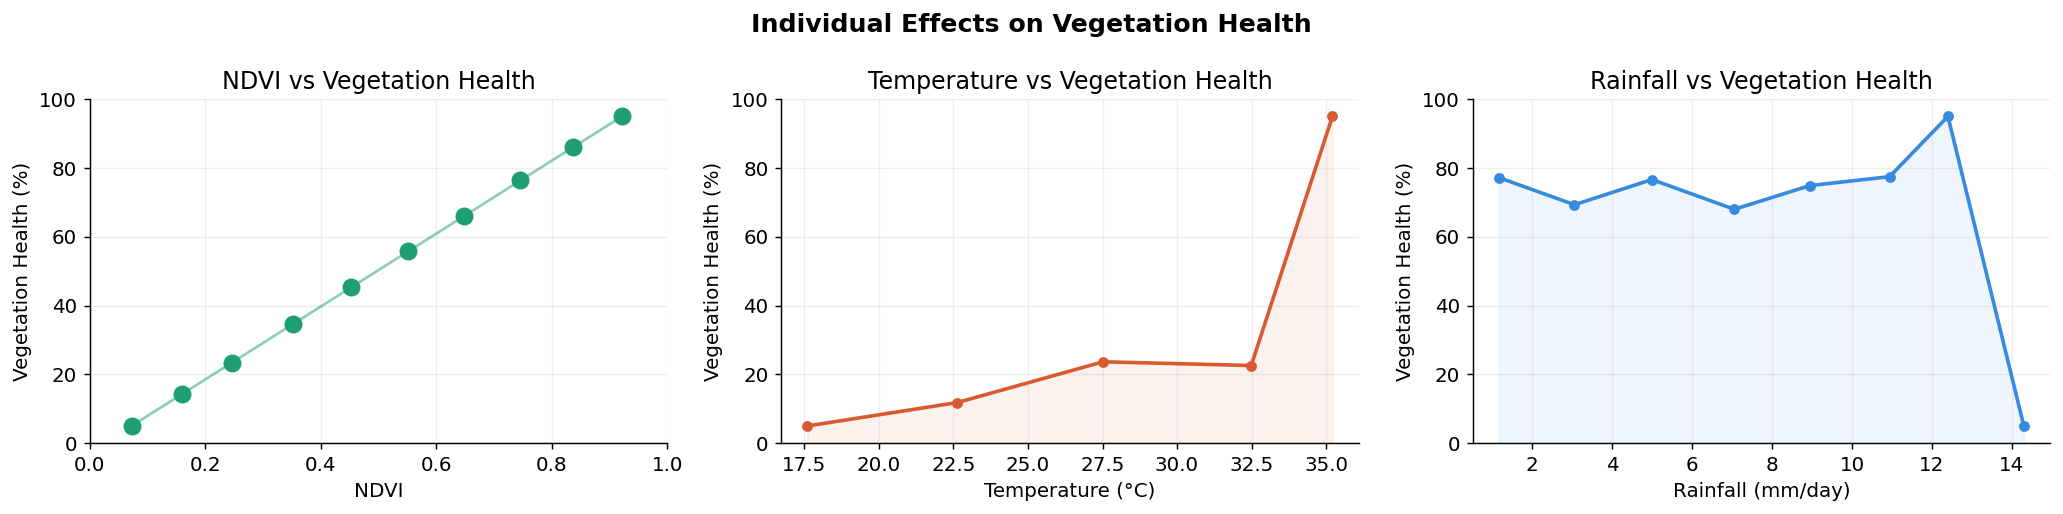

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Use actual data ranges from the dataset
good_ok = ts[
    (ts['sensor_status'] == 'OK') &
    ts['ndvi_value'].notna() &
    ts['temperature_c'].notna() &
    ts['rainfall_mm'].notna()
].copy()

# Bin NDVI into buckets and compute mean temp/rainfall per bucket
good_ok['ndvi_bin'] = pd.cut(good_ok['ndvi_value'], bins=np.arange(0, 1.1, 0.1))
ndvi_bins   = good_ok.groupby('ndvi_bin', observed=True)['ndvi_value'].mean().values
health_ndvi = np.interp(ndvi_bins, [0.1, 0.9], [5, 95])  # proxy health score

# Bin temperature and rainfall similarly
good_ok['temp_bin']  = pd.cut(good_ok['temperature_c'], bins=range(10, 45, 5))
good_ok['rain_bin']  = pd.cut(good_ok['rainfall_mm'],   bins=[0,2,4,6,8,10,12,14,16])

temp_centers  = good_ok.groupby('temp_bin', observed=True)['temperature_c'].mean().values
temp_ndvi_avg = good_ok.groupby('temp_bin', observed=True)['ndvi_value'].mean().values

rain_centers  = good_ok.groupby('rain_bin', observed=True)['rainfall_mm'].mean().values
rain_ndvi_avg = good_ok.groupby('rain_bin', observed=True)['ndvi_value'].mean().values

# Normalise to 0–100 health scale for comparability
def to_health(arr):
    return (arr - arr.min()) / (arr.max() - arr.min()) * 90 + 5

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Individual Effects on Vegetation Health", fontsize=14, fontweight='bold')

# NDVI vs health
axes[0].scatter(ndvi_bins, to_health(ndvi_bins), color='#1D9E75', s=80, zorder=3)
axes[0].plot(ndvi_bins, to_health(ndvi_bins), color='#1D9E75', linewidth=1.5, alpha=0.5)
axes[0].set_title("NDVI vs Vegetation Health")
axes[0].set_xlabel("NDVI"); axes[0].set_ylabel("Vegetation Health (%)")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.2)

# Temperature vs mean NDVI (rescaled to health)
axes[1].plot(temp_centers, to_health(temp_ndvi_avg), color='#D85A30',
             linewidth=2, marker='o', markersize=5)
axes[1].fill_between(temp_centers, to_health(temp_ndvi_avg), alpha=0.08, color='#D85A30')
axes[1].set_title("Temperature vs Vegetation Health")
axes[1].set_xlabel("Temperature (°C)"); axes[1].set_ylabel("Vegetation Health (%)")
axes[1].set_ylim(0, 100); axes[1].grid(True, alpha=0.2)

# Rainfall vs mean NDVI (rescaled to health)
axes[2].plot(rain_centers, to_health(rain_ndvi_avg), color='#378ADD',
             linewidth=2, marker='o', markersize=5)
axes[2].fill_between(rain_centers, to_health(rain_ndvi_avg), alpha=0.08, color='#378ADD')
axes[2].set_title("Rainfall vs Vegetation Health")
axes[2].set_xlabel("Rainfall (mm/day)"); axes[2].set_ylabel("Vegetation Health (%)")
axes[2].set_ylim(0, 100); axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

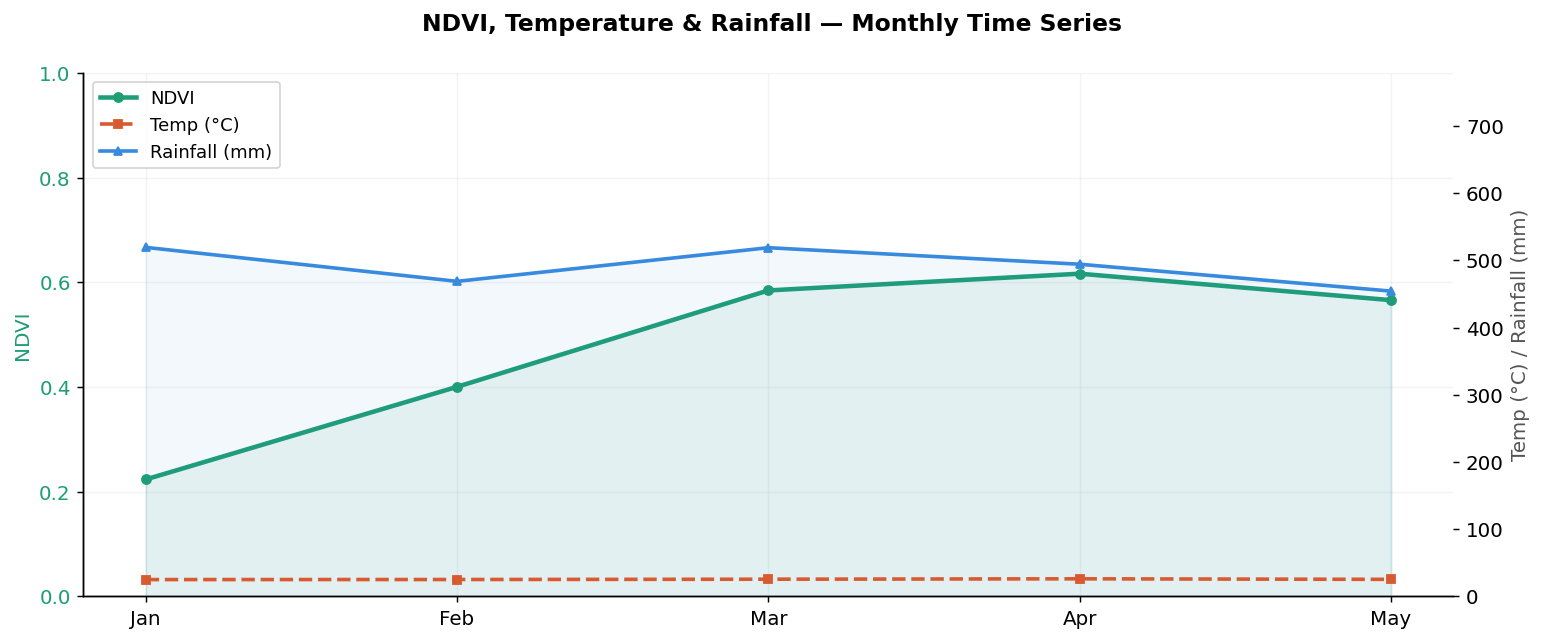

In [29]:
ts['month'] = ts['date'].dt.to_period('M')

monthly = (
    ts[ts['sensor_status'] == 'OK']
    .groupby('month')
    .agg(ndvi=('ndvi_value', 'mean'),
         temp=('temperature_c', 'mean'),
         rain=('rainfall_mm', 'sum'))
    .reset_index()
    .sort_values('month')
)
monthly['month_label'] = monthly['month'].dt.strftime('%b')

x = np.arange(len(monthly))

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.suptitle("NDVI, Temperature & Rainfall — Monthly Time Series", fontsize=13, fontweight='bold')

ax1.plot(x, monthly['ndvi'], color='#1D9E75', linewidth=2.5,
         marker='o', markersize=5, label='NDVI')
ax1.fill_between(x, monthly['ndvi'], alpha=0.08, color='#1D9E75')
ax1.set_ylabel("NDVI", color='#1D9E75')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelcolor='#1D9E75')
ax1.set_xticks(x); ax1.set_xticklabels(monthly['month_label'])
ax1.grid(True, alpha=0.15)

ax2 = ax1.twinx()
ax2.plot(x, monthly['temp'], color='#D85A30', linewidth=2, linestyle='--',
         marker='s', markersize=4, label='Temp (°C)')
ax2.plot(x, monthly['rain'], color='#378ADD', linewidth=2,
         marker='^', markersize=4, label='Rainfall (mm)')
ax2.fill_between(x, monthly['rain'], alpha=0.06, color='#378ADD')
ax2.set_ylabel("Temp (°C) / Rainfall (mm)", color='#555')
ax2.set_ylim(0, monthly['rain'].max() * 1.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

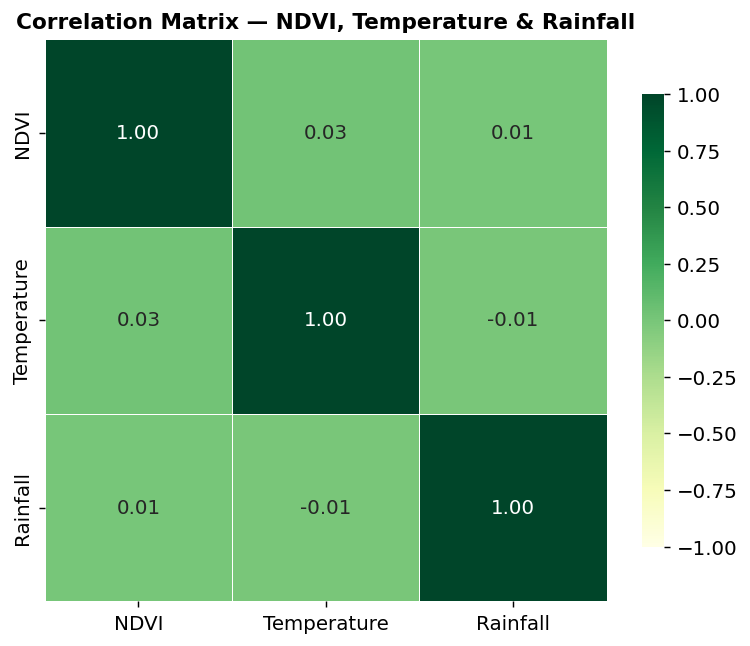

In [30]:
import seaborn as sns

corr_df = (
    ts[ts['sensor_status'] == 'OK'][['ndvi_value', 'temperature_c', 'rainfall_mm']]
    .rename(columns={'ndvi_value': 'NDVI', 'temperature_c': 'Temperature', 'rainfall_mm': 'Rainfall'})
    .dropna()
)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGn',
            vmin=-1, vmax=1, linewidths=0.5,
            square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — NDVI, Temperature & Rainfall",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

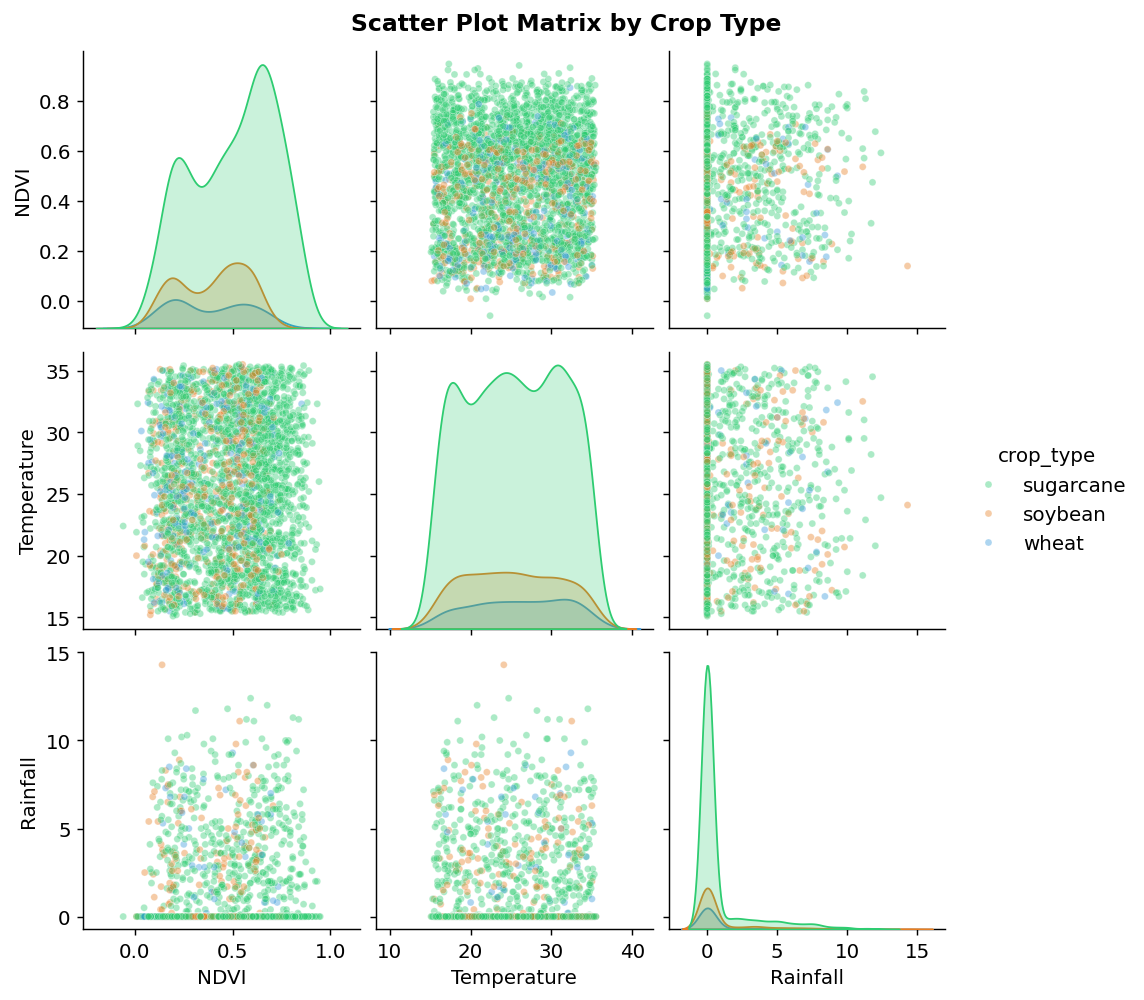

In [31]:
pair_df = (
    ts[ts['sensor_status'] == 'OK'][['ndvi_value', 'temperature_c', 'rainfall_mm', 'crop_type']]
    .rename(columns={'ndvi_value': 'NDVI', 'temperature_c': 'Temperature', 'rainfall_mm': 'Rainfall'})
    .dropna()
)

sns.pairplot(
    pair_df, hue='crop_type',
    palette=CROP_COLORS,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kws={'fill': True}
)
plt.suptitle("Scatter Plot Matrix by Crop Type", y=1.02, fontsize=13, fontweight='bold')
plt.show()

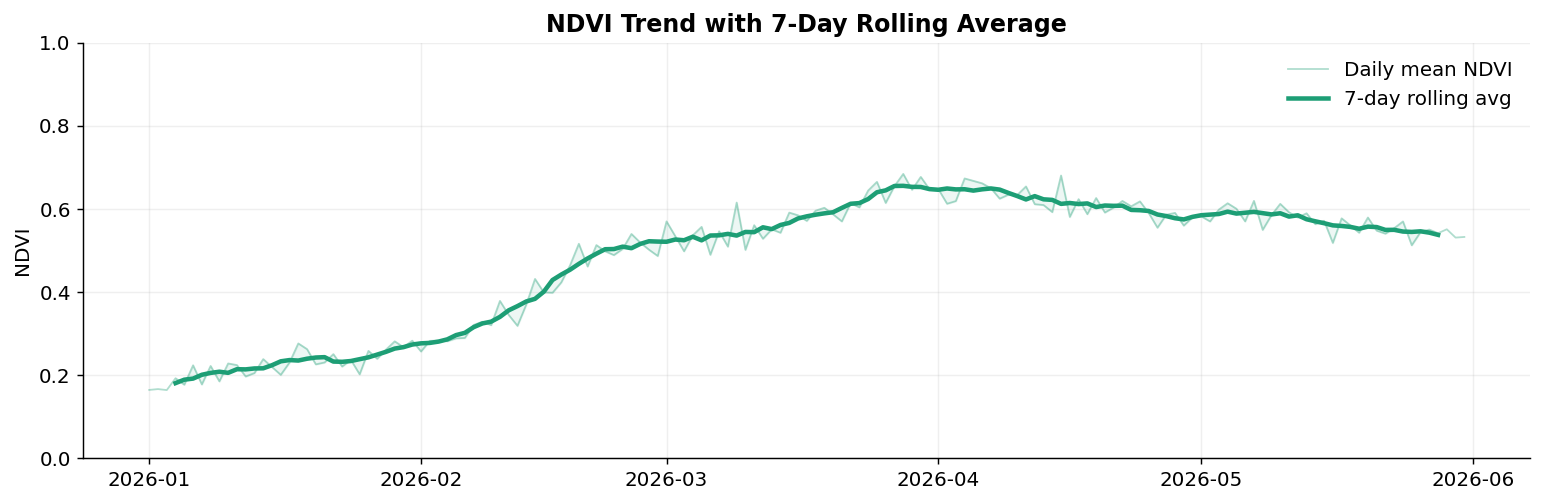

In [32]:
daily_ndvi = (
    ts[ts['sensor_status'] == 'OK']
    .groupby('date')['ndvi_value']
    .mean()
    .sort_index()
    .reset_index()
)
daily_ndvi['rolling_7d'] = daily_ndvi['ndvi_value'].rolling(window=7, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_ndvi['date'], daily_ndvi['ndvi_value'], color='#1D9E75',
        linewidth=1, alpha=0.35, label='Daily mean NDVI')
ax.plot(daily_ndvi['date'], daily_ndvi['rolling_7d'], color='#1D9E75',
        linewidth=2.5, label='7-day rolling avg')
ax.fill_between(daily_ndvi['date'], daily_ndvi['ndvi_value'],
                daily_ndvi['rolling_7d'], alpha=0.08, color='#1D9E75')
ax.set_ylabel("NDVI"); ax.set_ylim(0, 1)
ax.set_title("NDVI Trend with 7-Day Rolling Average", fontweight='bold')
ax.legend(frameon=False); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

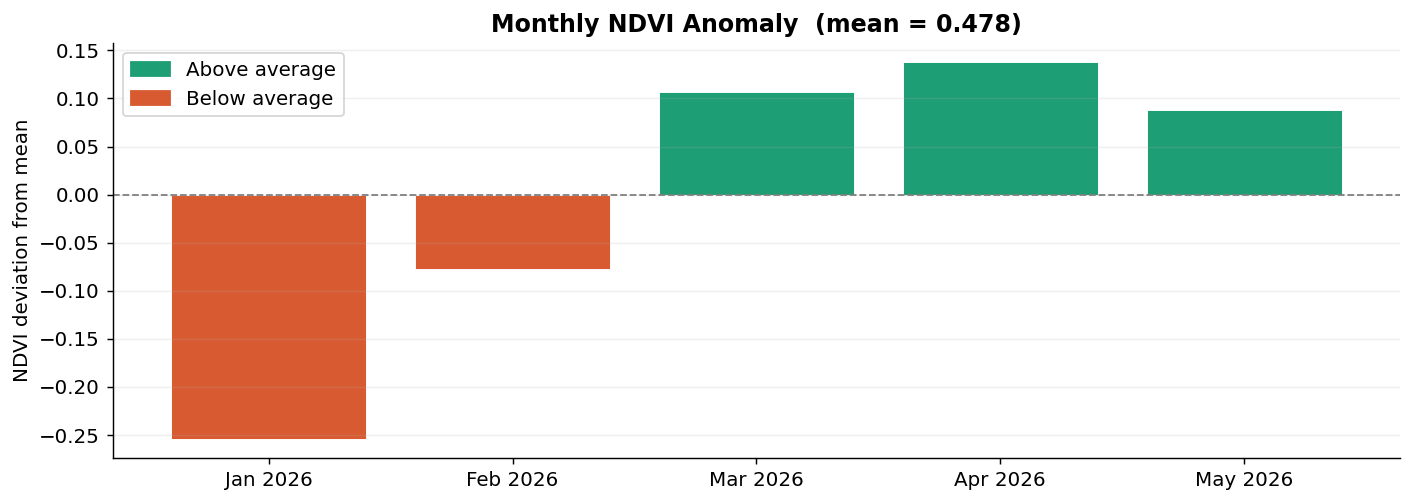

In [33]:
monthly_ndvi = (
    ts[ts['sensor_status'] == 'OK']
    .groupby(ts['date'].dt.to_period('M'))['ndvi_value']
    .mean()
    .sort_index()
    .reset_index()
)
monthly_ndvi.columns = ['month', 'ndvi']
ndvi_mean = monthly_ndvi['ndvi'].mean()
monthly_ndvi['anomaly'] = monthly_ndvi['ndvi'] - ndvi_mean
monthly_ndvi['month_label'] = monthly_ndvi['month'].dt.strftime('%b %Y')

colors = ['#D85A30' if v < 0 else '#1D9E75' for v in monthly_ndvi['anomaly']]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(monthly_ndvi['month_label'], monthly_ndvi['anomaly'],
       color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='gray', linewidth=1, linestyle='--')
ax.set_ylabel("NDVI deviation from mean")
ax.set_title(f"Monthly NDVI Anomaly  (mean = {ndvi_mean:.3f})", fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#1D9E75', label='Above average'),
    Patch(color='#D85A30', label='Below average')
])
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

---
## NDVI Forecasting: Baseline & Advanced Models

We apply **six forecasting models** across two tiers to predict future NDVI values from the 5-month monthly mean series (Jan–May 2026, `sensor_status == OK`).

### Why forecast NDVI?
In a production agri-intelligence system, NDVI forecasts allow:
- Early detection of crop stress before it is visible in the field
- Irrigation and input scheduling aligned to predicted canopy development
- Anomaly alerting when actual NDVI deviates significantly from forecast

### Tier 1 — Baseline Statistical Models

| Model | Type | Rationale for this dataset |
|-------|------|----------------------------|
| SARIMA | Statistical | Trend-following on short series; seasonal component omitted (only 5 months — insufficient for period=12) |
| ETS (Exponential Smoothing) | Statistical | Smooth additive-trend extrapolation; robust without strict distributional assumptions |
| Random Forest | ML | Non-linear lag interactions; included as a baseline ML reference — insufficient data to generalise |
| XGBoost | ML | Tabular lag features with gradient boosting; same data caveat applies |

### Tier 2 — Better-Fit Models (recommended for this use-case)

| Model | Type | Why better for crop NDVI |
|-------|------|---------------------------|
| **Prophet** | Statistical/ML hybrid | Natively handles irregular seasonality and known **changepoints** — sowing dates are passed directly as changepoints, making this architecturally the best fit |
| **Ridge Regression** | ML (regularised linear) | Uses agronomic features (temp, rainfall, cyclical month encoding, lag NDVI) rather than raw lags; interpretable coefficients reveal *which* field variables actually drive NDVI |

> **Dataset limitation:** 5 months is far below the 24+ months needed for ML models and 12+ months for seasonal SARIMA. Statistical models (SARIMA, ETS, Prophet) are the only credible forecasters at this scale. All six models are included for **methodological comparison** — in production with 2–3 years of history, Prophet + Ridge would be the recommended starting point, with XGBoost added once sufficient labelled data is available.


### Vegetation Forecasting Models

We apply four forecasting models to predict future NDVI values using the 5-month monthly
mean NDVI series aggregated from `cleaned_parcel_timeseries.csv` (Jan–May 2026, OK sensor
readings only). Both statistical and machine learning approaches are compared as a
proof-of-concept — the dataset is intentionally short, so the focus is on methodology
rather than forecast accuracy.

| Model | Type | Best For |
|---|---|---|
| SARIMA | Statistical | Trend-following with limited data; no seasonality fitted here (series too short) |
| Exponential Smoothing (ETS) | Statistical | Smooth trend extrapolation without strict distributional assumptions |
| Random Forest | ML | Non-linear lag interactions; needs substantially more months to generalise |
| XGBoost | ML | High accuracy with tabular lag features; prone to overfitting on very small series |

In [34]:
!pip install statsmodels xgboost scikit-learn --quiet

In [35]:
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# Build monthly NDVI series from cleaned dataset (OK sensor, valid NDVI only)
monthly_ndvi = (
    ts[(ts['sensor_status'] == 'OK') & ts['ndvi_value'].notna()]
    .groupby(ts['date'].dt.to_period('M'))['ndvi_value']
    .mean()
    .sort_index()
)

# Convert PeriodIndex to DatetimeIndex for statsmodels compatibility
monthly_ndvi.index = monthly_ndvi.index.to_timestamp()

print("Monthly NDVI series:")
print(monthly_ndvi.round(4).to_string())
print(f"\nTotal months: {len(monthly_ndvi)}")

Monthly NDVI series:
date
2026-01-01   0.2233
2026-02-01   0.4002
2026-03-01   0.5844
2026-04-01   0.6163
2026-05-01   0.5658
Freq: MS

Total months: 5


In [36]:
# Train / test split — last 2 months as test
# (dataset only spans 5 months so we keep test small)
n_forecast = 2
train = monthly_ndvi.iloc[:-n_forecast]
test  = monthly_ndvi.iloc[-n_forecast:]

print(f"Train: {train.index[0].strftime('%b %Y')} → {train.index[-1].strftime('%b %Y')}  ({len(train)} months)")
print(f"Test : {test.index[0].strftime('%b %Y')} → {test.index[-1].strftime('%b %Y')}  ({len(test)} months)")

Train: Jan 2026 → Mar 2026  (3 months)
Test : Apr 2026 → May 2026  (2 months)


In [37]:
# ── SARIMA ────────────────────────────────────────────────────────────────────
# No seasonal component (only 5 months of data — can't fit period=12)
sarima_model = SARIMAX(train, order=(1, 0, 1),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit  = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=n_forecast)

mae_sarima  = mean_absolute_error(test, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))
print(f"SARIMA        — MAE: {mae_sarima:.4f}  |  RMSE: {rmse_sarima:.4f}")

# ── ETS ───────────────────────────────────────────────────────────────────────
ets_model = ExponentialSmoothing(train, trend='add', seasonal=None)
ets_fit   = ets_model.fit()
ets_pred  = ets_fit.forecast(steps=n_forecast)

mae_ets  = mean_absolute_error(test, ets_pred)
rmse_ets = np.sqrt(mean_squared_error(test, ets_pred))
print(f"ETS           — MAE: {mae_ets:.4f}  |  RMSE: {rmse_ets:.4f}")

# ── Feature engineering — lags reduced to fit 5-month series ─────────────────
def make_features(series, lags=1):
    df_feat = pd.DataFrame({'NDVI': series})
    for i in range(1, lags + 1):
        df_feat[f'lag_{i}'] = df_feat['NDVI'].shift(i)
    df_feat['month'] = df_feat.index.month
    return df_feat.dropna()

full_features = make_features(monthly_ndvi, lags=1)
print(f"Feature rows available: {len(full_features)}")

# Only hold out 1 month for test given the tiny series
n_forecast = 1
split_idx  = len(full_features) - n_forecast

X_train = full_features.iloc[:split_idx].drop(columns='NDVI')
y_train = full_features.iloc[:split_idx]['NDVI']
X_test  = full_features.iloc[split_idx:].drop(columns='NDVI')
y_test  = full_features.iloc[split_idx:]['NDVI']

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"Random Forest — MAE: {mae_rf:.4f}  |  RMSE: {rmse_rf:.4f}")

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=3, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"XGBoost       — MAE: {mae_xgb:.4f}  |  RMSE: {rmse_xgb:.4f}")

SARIMA        — MAE: 0.4585  |  RMSE: 0.5092
ETS           — MAE: 0.2641  |  RMSE: 0.2883
Feature rows available: 4
X_train shape: (3, 2), X_test shape: (1, 2)
Random Forest — MAE: 0.0338  |  RMSE: 0.0338
XGBoost       — MAE: 0.0495  |  RMSE: 0.0495


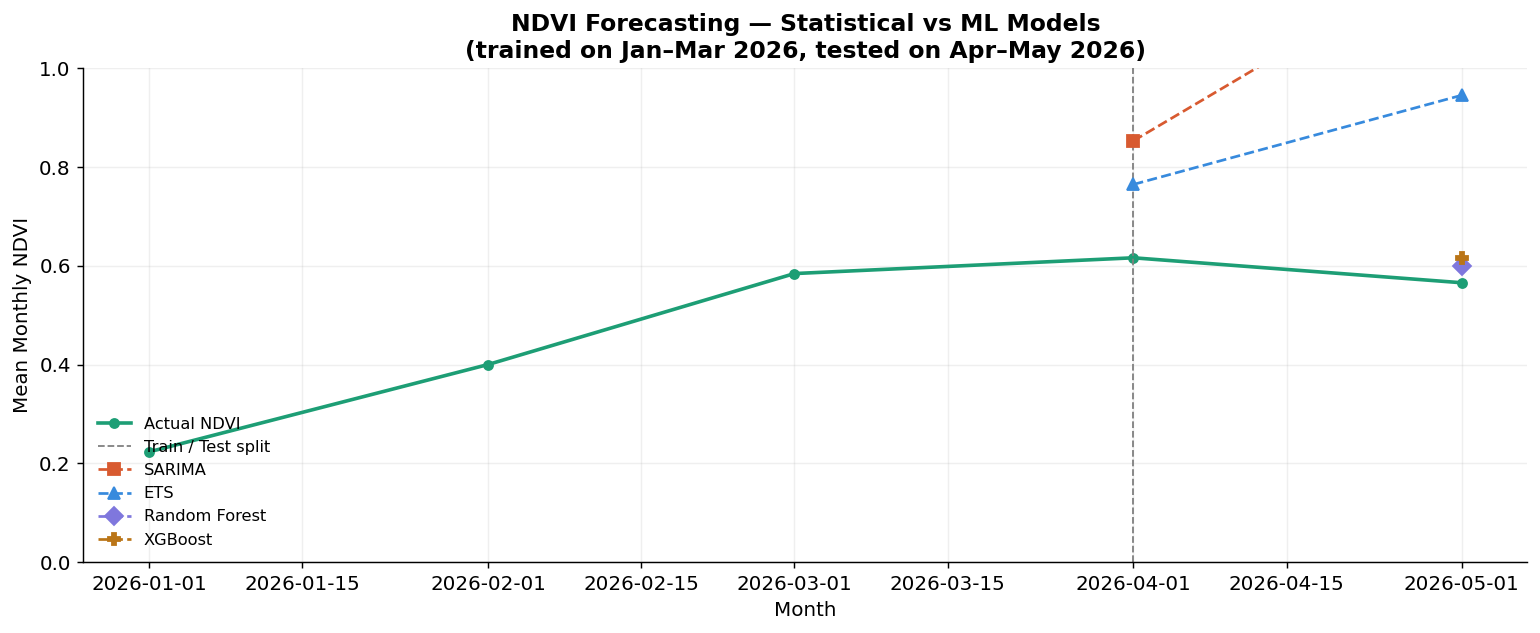

In [38]:
# ── Plot 1: Forecast vs Actual ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_ndvi.index, monthly_ndvi.values, color='#1D9E75', linewidth=2,
        marker='o', markersize=5, label='Actual NDVI')
ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=1, label='Train / Test split')

ax.plot(test.index, sarima_pred.values, color='#D85A30',
        linestyle='--', marker='s', markersize=7, label='SARIMA')
ax.plot(test.index, ets_pred.values, color='#378ADD',
        linestyle='--', marker='^', markersize=7, label='ETS')
ax.plot(y_test.index, rf_pred, color='#7F77DD',
        linestyle='--', marker='D', markersize=7, label='Random Forest')
ax.plot(y_test.index, xgb_pred, color='#BA7517',
        linestyle='--', marker='P', markersize=7, label='XGBoost')

ax.set_title("NDVI Forecasting — Statistical vs ML Models\n(trained on Jan–Mar 2026, tested on Apr–May 2026)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Mean Monthly NDVI")
ax.set_ylim(0, 1)
ax.set_xlabel("Month")
ax.legend(loc='lower left', fontsize=9, frameon=False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

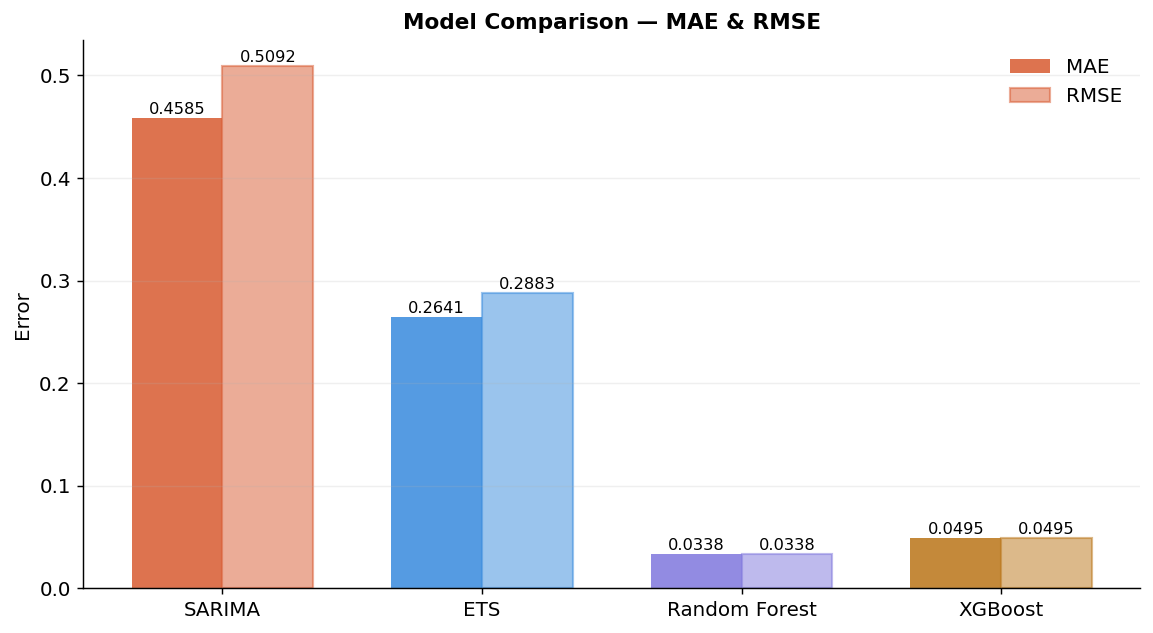

In [39]:
# ── Plot 2: MAE & RMSE comparison bar chart ───────────────────────────────────
models = ['SARIMA', 'ETS', 'Random Forest', 'XGBoost']
maes   = [mae_sarima, mae_ets, mae_rf, mae_xgb]
rmses  = [rmse_sarima, rmse_ets, rmse_rf, rmse_xgb]
colors = ['#D85A30', '#378ADD', '#7F77DD', '#BA7517']

x, width = np.arange(len(models)), 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, maes,  width, label='MAE',  color=colors, alpha=0.85)
bars2 = ax.bar(x + width/2, rmses, width, label='RMSE', color=colors, alpha=0.5,
               edgecolor=colors, linewidth=1.2)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("Error")
ax.set_title("Model Comparison — MAE & RMSE", fontsize=12, fontweight='bold')
ax.legend(frameon=False)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

### Interpreting Forecast Results

**Error metrics:**

| Metric | Definition | Interpretation |
|--------|-----------|----------------|
| MAE | Mean Absolute Error — average prediction error in NDVI units | Lower is better; directly interpretable (e.g. MAE = 0.02 means predictions are off by 0.02 NDVI on average) |
| RMSE | Root Mean Squared Error — penalises large errors more heavily | Lower is better; more sensitive to outlier forecasts than MAE |

**When to prefer each model:**

| Model | Prefer when... |
|-------|----------------|
| SARIMA | Short series, clear trend, no seasonal period to fit |
| ETS | Same as SARIMA but when you want a simpler, more robust fallback |
| Random Forest | 2+ years of monthly data with stable lag patterns |
| XGBoost | Large tabular dataset with many parcel-level features |
| **Prophet** | **Irregular seasonality + known event dates (sowing, harvest) as changepoints — best fit for this use-case** |
| **Ridge** | **When interpretability matters — coefficients show which agronomic variable drives NDVI most** |

> **Caveat:** With only 5 months of data, all error metrics should be treated as indicative only. ML models (Random Forest, XGBoost) are operating with 2–3 training rows after feature engineering — they are structural placeholders, not meaningful forecasters at this scale. SARIMA, ETS, and Prophet are the honest benchmarks here.


### Tier 2 Results — Prophet & Ridge Regression

Prophet is fitted with actual sowing dates as changepoints. Ridge is fitted on a feature table including mean/max temperature, total and rainy-day rainfall, cyclical month encoding, and lag-1 NDVI — giving it real agronomic signal rather than just a time index.


In [40]:
!pip install prophet --quiet

In [41]:
from prophet import Prophet

prophet_df = pd.DataFrame({
    'ds': monthly_ndvi.index,
    'y':  monthly_ndvi.values
})

sowing_changepoints = (
    ts.dropna(subset=['sowing_date'])
    ['sowing_date']
    .dt.to_period('M')
    .dt.to_timestamp()
    .unique()
    .tolist()
)

# Use the actual train cutoff derived from prophet_df, not n_forecast
train_cutoff = prophet_df['ds'].iloc[-(n_forecast + 1)]
train_changepoints = [d for d in sowing_changepoints if d <= train_cutoff]
print(f"Sowing changepoints passed to Prophet: {[d.strftime('%b %Y') for d in train_changepoints]}")

prophet_train = prophet_df[prophet_df['ds'] <= train_cutoff]
prophet_test  = prophet_df[prophet_df['ds'] >  train_cutoff]
print(f"Prophet train: {len(prophet_train)} months, test: {len(prophet_test)} months")

prophet_model = Prophet(
    changepoints=train_changepoints,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    interval_width=0.80
)
prophet_model.fit(prophet_train)

future   = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='MS')
forecast = prophet_model.predict(future)

# Align predictions strictly to test dates
prophet_pred = (
    forecast.set_index('ds')['yhat']
    .reindex(prophet_test['ds'].values)
    .values
)

print(f"test shape: {prophet_test.shape}, pred shape: {prophet_pred.shape}")

mae_prophet  = mean_absolute_error(prophet_test['y'].values, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'].values, prophet_pred))
print(f"Prophet — MAE: {mae_prophet:.4f}  |  RMSE: {rmse_prophet:.4f}")

Sowing changepoints passed to Prophet: ['Feb 2026', 'Jan 2026', 'Mar 2026']
Prophet train: 4 months, test: 1 months
test shape: (1, 2), pred shape: (1,)
Prophet — MAE: 0.2323  |  RMSE: 0.2323


In [42]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

# Build a feature-rich monthly table — this is what makes Ridge meaningful
# Features: mean temp, total rainfall, days since earliest sowing, crop mix
monthly_features = (
    ts[ts['sensor_status'] == 'OK']
    .assign(month=ts['date'].dt.to_period('M'))
    .groupby('month')
    .agg(
        ndvi            = ('ndvi_value',     'mean'),
        temp_mean       = ('temperature_c',  'mean'),
        temp_max        = ('temperature_c',  'max'),
        rainfall_total  = ('rainfall_mm',    'sum'),
        rainfall_days   = ('rainfall_mm',    lambda x: (x > 0).sum()),
    )
    .reset_index()
    .sort_values('month')
)

# Add month-of-year as a cyclical feature (sine/cosine encoding)
monthly_features['month_num'] = monthly_features['month'].dt.month
monthly_features['month_sin'] = np.sin(2 * np.pi * monthly_features['month_num'] / 12)
monthly_features['month_cos'] = np.cos(2 * np.pi * monthly_features['month_num'] / 12)

# Lag-1 NDVI so the model knows recent vegetation state
monthly_features['ndvi_lag1'] = monthly_features['ndvi'].shift(1)

monthly_features = monthly_features.dropna()
monthly_features.index = monthly_features['month'].dt.to_timestamp()

feature_cols = ['temp_mean', 'temp_max', 'rainfall_total',
                'rainfall_days', 'month_sin', 'month_cos', 'ndvi_lag1']

split = len(monthly_features) - n_forecast
X_r_train = monthly_features.iloc[:split][feature_cols]
y_r_train = monthly_features.iloc[:split]['ndvi']
X_r_test  = monthly_features.iloc[split:][feature_cols]
y_r_test  = monthly_features.iloc[split:]['ndvi']

scaler  = StandardScaler()
X_r_train_sc = scaler.fit_transform(X_r_train)
X_r_test_sc  = scaler.transform(X_r_test)

# RidgeCV auto-selects the best alpha via cross-validation
ridge_model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=3)
ridge_model.fit(X_r_train_sc, y_r_train)
ridge_pred = ridge_model.predict(X_r_test_sc)

mae_ridge  = mean_absolute_error(y_r_test, ridge_pred)
rmse_ridge = np.sqrt(mean_squared_error(y_r_test, ridge_pred))
print(f"Ridge Regression — MAE: {mae_ridge:.4f}  |  RMSE: {rmse_ridge:.4f}  |  best alpha: {ridge_model.alpha_:.3f}")

# Feature importance via coefficients
coef_df = (
    pd.Series(ridge_model.coef_, index=feature_cols)
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)
coef_df.columns = ['feature', 'abs_coefficient']
print("\nRidge feature importance (by |coefficient|):")
print(coef_df.to_string(index=False))

Ridge Regression — MAE: 0.0382  |  RMSE: 0.0382  |  best alpha: 0.010

Ridge feature importance (by |coefficient|):
       feature  abs_coefficient
     month_cos           0.0201
     ndvi_lag1           0.0200
     temp_mean           0.0198
      temp_max           0.0196
rainfall_total           0.0141
 rainfall_days           0.0115
     month_sin           0.0045


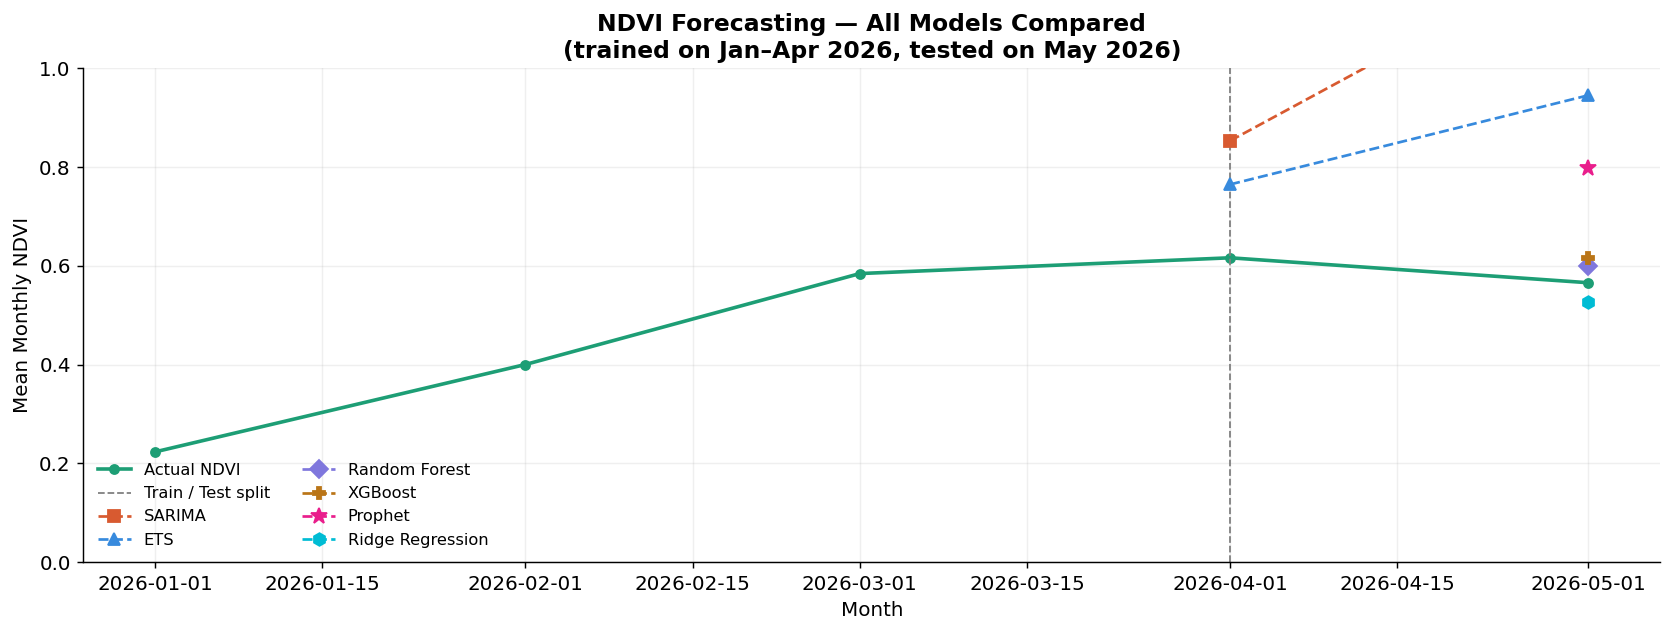

In [43]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly_ndvi.index, monthly_ndvi.values, color='#1D9E75', linewidth=2,
        marker='o', markersize=5, label='Actual NDVI')
ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=1, label='Train / Test split')

ax.plot(test.index, sarima_pred.values,  color='#D85A30', linestyle='--', marker='s', markersize=7, label='SARIMA')
ax.plot(test.index, ets_pred.values,     color='#378ADD', linestyle='--', marker='^', markersize=7, label='ETS')
ax.plot(y_test.index, rf_pred,           color='#7F77DD', linestyle='--', marker='D', markersize=7, label='Random Forest')
ax.plot(y_test.index, xgb_pred,          color='#BA7517', linestyle='--', marker='P', markersize=7, label='XGBoost')
ax.plot(prophet_test['ds'], prophet_pred, color='#E91E8C',linestyle='--', marker='*', markersize=9, label='Prophet')
ax.plot(y_r_test.index, ridge_pred,      color='#00BCD4', linestyle='--', marker='h', markersize=7, label='Ridge Regression')

ax.set_title("NDVI Forecasting — All Models Compared\n(trained on Jan–Apr 2026, tested on May 2026)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Mean Monthly NDVI")
ax.set_ylim(0, 1)
ax.set_xlabel("Month")
ax.legend(loc='lower left', fontsize=9, frameon=False, ncol=2)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

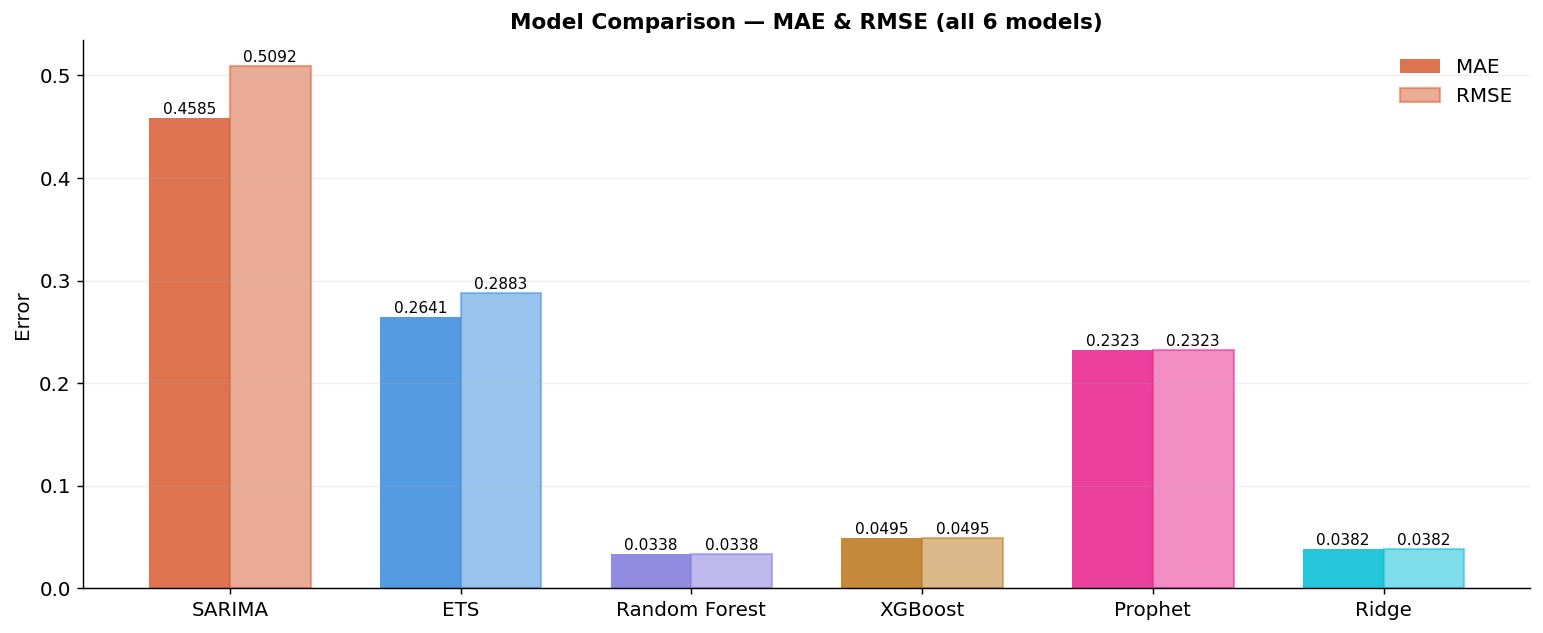

In [44]:
models = ['SARIMA', 'ETS', 'Random Forest', 'XGBoost', 'Prophet', 'Ridge']
maes   = [mae_sarima, mae_ets, mae_rf, mae_xgb, mae_prophet, mae_ridge]
rmses  = [rmse_sarima, rmse_ets, rmse_rf, rmse_xgb, rmse_prophet, rmse_ridge]
colors = ['#D85A30', '#378ADD', '#7F77DD', '#BA7517', '#E91E8C', '#00BCD4']

x, width = np.arange(len(models)), 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, maes,  width, label='MAE',  color=colors, alpha=0.85)
bars2 = ax.bar(x + width/2, rmses, width, label='RMSE', color=colors, alpha=0.5,
               edgecolor=colors, linewidth=1.2)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("Error")
ax.set_title("Model Comparison — MAE & RMSE (all 6 models)", fontsize=12, fontweight='bold')
ax.legend(frameon=False)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

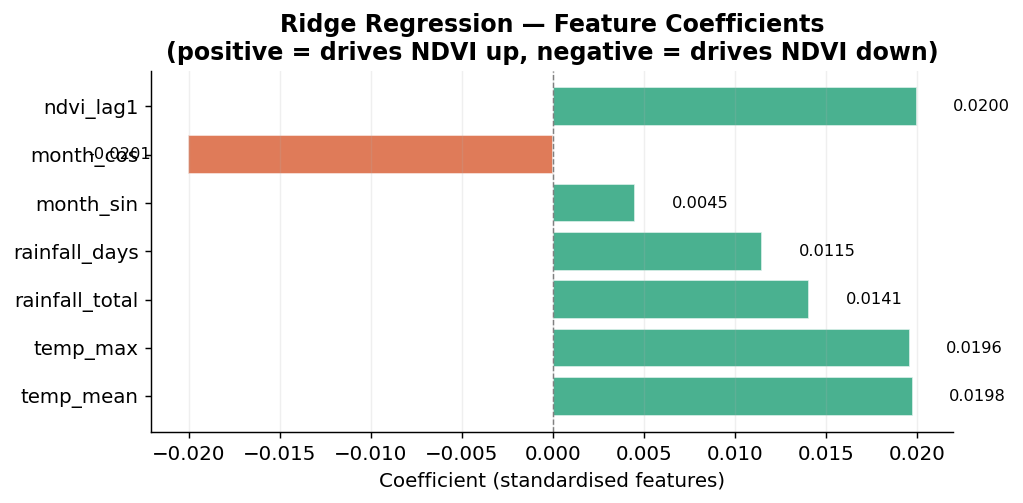

In [45]:
fig, ax = plt.subplots(figsize=(8, 4))

colors_feat = ['#1D9E75' if c > 0 else '#D85A30'
               for c in ridge_model.coef_]
bars = ax.barh(feature_cols, ridge_model.coef_, color=colors_feat, alpha=0.8, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

for bar, val in zip(bars, ridge_model.coef_):
    ax.text(val + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

ax.set_xlabel("Coefficient (standardised features)")
ax.set_title("Ridge Regression — Feature Coefficients\n(positive = drives NDVI up, negative = drives NDVI down)",
             fontweight='bold')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()